<!-- Imports and Setup -->
<!-- to load tools -->

In [1]:
# Cell 1: Imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, f1_score, confusion_matrix, classification_report
import xgboost as xgb

import warnings
warnings.filterwarnings('ignore') # Keeps your notebook clean from warnings

<!-- Data Loading & Stratified Split -->
<!-- the data preparation -->

In [2]:
# Cell 2: Data Prep
# NOTE: To run the other dataset, change to 'Fraud_Data.csv' and 'class'
DATA_FILE = '../data/raw/creditcard.csv' 
TARGET_COL = 'Class'

print(f"Loading {DATA_FILE}...")
df = pd.read_csv(DATA_FILE)

# Separate features and target
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# Stratified Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")
print(f"Fraud cases in test set: {sum(y_test == 1)}")

Loading ../data/raw/creditcard.csv...
Training data shape: (227845, 30)
Testing data shape: (56962, 30)
Fraud cases in test set: 98


Baseline Model (Logistic Regression)
This trains your interpretable baseline model and evaluates it using Cross-Validation.

In [3]:
# Cell 3: Baseline Model
print("Training Baseline: Logistic Regression...")

# Initialize with balanced class weights
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

# Set up Stratified K-Fold for reliable cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Run Cross-Validation
scoring_metrics = ['f1', 'average_precision']
cv_results_lr = cross_validate(log_reg, X_train, y_train, cv=cv, scoring=scoring_metrics)

print(f"CV F1-Score: {np.mean(cv_results_lr['test_f1']):.4f} (+/- {np.std(cv_results_lr['test_f1']):.4f})")
print(f"CV AUC-PR: {np.mean(cv_results_lr['test_average_precision']):.4f} (+/- {np.std(cv_results_lr['test_average_precision']):.4f})")

# Fit on the full training set and predict on the holdout test set
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

Training Baseline: Logistic Regression...
CV F1-Score: 0.0973 (+/- 0.0087)
CV AUC-PR: 0.7534 (+/- 0.0496)


<!-- Ensemble Model (XGBoost) with Basic Tuning
This builds your advanced model and handles the heavy imbalance mathematically. -->

In [4]:
# Cell 4: XGBoost Ensemble
print("Training Ensemble: XGBoost...")

# Calculate scale_pos_weight to handle extreme imbalance
neg_class = y_train.value_counts()[0]
pos_class = y_train.value_counts()[1]
scale_weight = neg_class / pos_class

xgb_model = xgb.XGBClassifier(scale_pos_weight=scale_weight, eval_metric='logloss', random_state=42)

# Basic Hyperparameter Grid (Kept small so it runs relatively quickly in a notebook)
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5]
}

# Grid Search with CV
grid_search = GridSearchCV(
    estimator=xgb_model, 
    param_grid=param_grid, 
    cv=cv, 
    scoring='average_precision', # Optimize for AUC-PR
    n_jobs=-1 # Uses all available CPU cores
)

grid_search.fit(X_train, y_train)
best_xgb = grid_search.best_estimator_

print(f"Best XGBoost Params: {grid_search.best_params_}")

# Predict on holdout test set
y_pred_xgb = best_xgb.predict(X_test)
y_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]

Training Ensemble: XGBoost...
Best XGBoost Params: {'max_depth': 5, 'n_estimators': 100}


Final Evaluation & Model Comparison
This generates the side-by-side comparison table you need for your deliverables.

In [5]:
# Cell 5: Model Evaluation Table
print("--- Final Test Set Evaluation ---")

# 1. Build the list flatly on individual lines to avoid indentation bugs
models_to_check = []
models_to_check.append(("Logistic Regression", y_pred_lr, y_proba_lr))
models_to_check.append(("XGBoost", y_pred_xgb, y_proba_xgb))

results = []

# 2. Run the evaluation loop
for model_name, y_pred, y_proba in models_to_check:
    auc_pr = average_precision_score(y_test, y_proba)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    results.append({
        "Model": model_name,
        "AUC-PR": round(auc_pr, 4),
        "F1-Score": round(f1, 4),
        "True Negatives": cm[0, 0],
        "False Positives": cm[0, 1],
        "False Negatives": cm[1, 0],
        "True Positives": cm[1, 1]
    })

# 3. Convert and display the final summary table
results_df = pd.DataFrame(results)
results_df

--- Final Test Set Evaluation ---


,Model,AUC-PR,F1-Score,True Negatives,False Positives,False Negatives,True Positives
0,Logistic Regression,0.7233,0.0873,54990,1874,8,90
1,XGBoost,0.8721,0.8542,56852,12,16,82


While building the model (Task 2) proves how well it works, Model Explainability (Task 3) proves why it works. This is what you will actually present to business stakeholders.

The Python Code for Explainability
This code assumes you are continuing from Task 2 and have your trained model (e.g., best_xgb), your test features (X_test), your true labels (y_test), and your model's predictions (y_pred).

Generating Built-in Feature Importance...


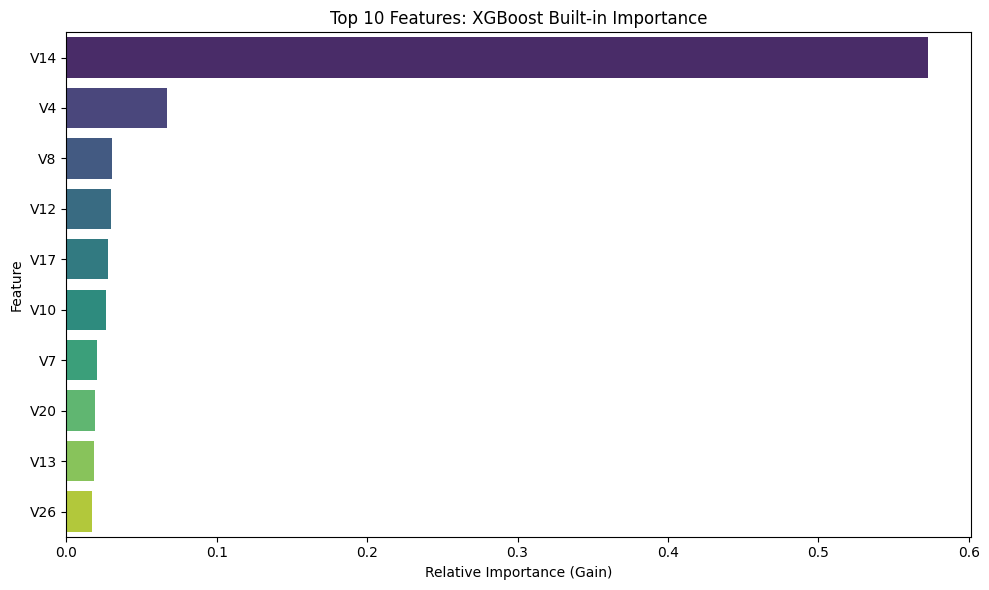

Calculating SHAP values (this may take a moment)...


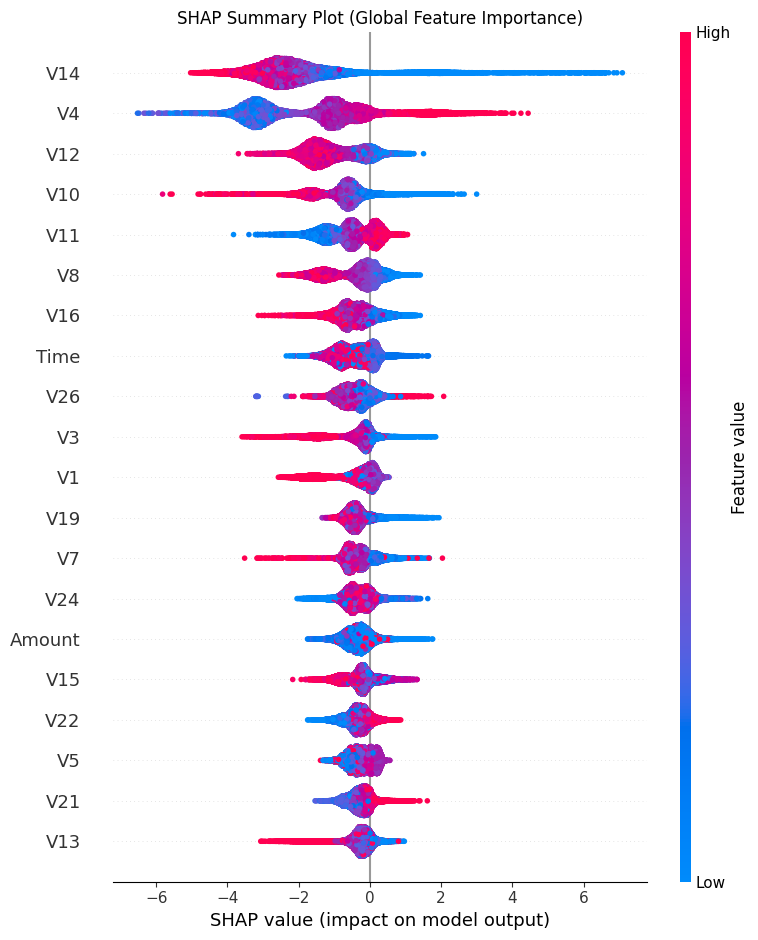

Generating Force Plot for: True Positive (Correctly Flagged Fraud) (Index: 840)


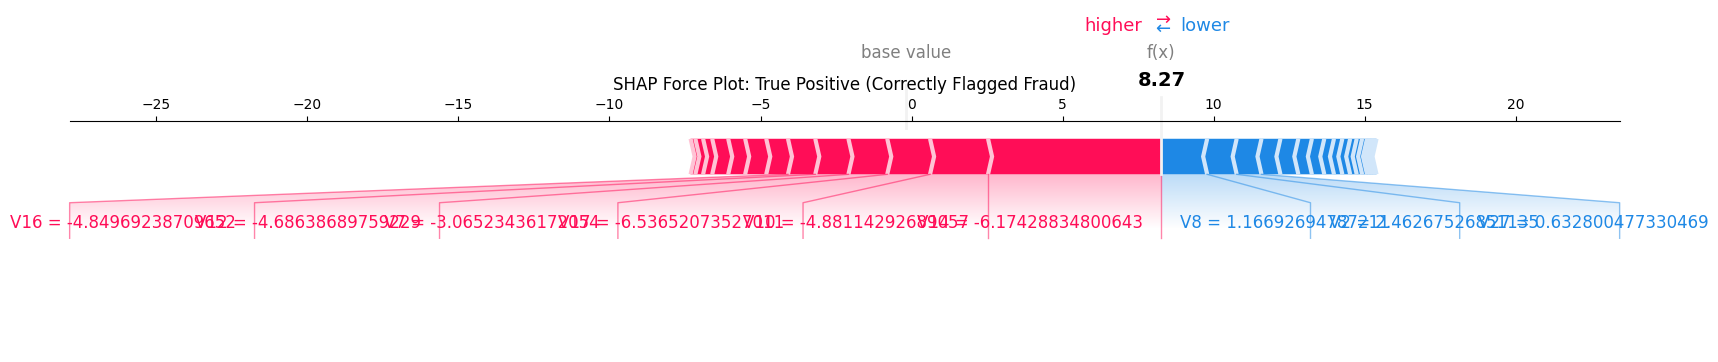

Generating Force Plot for: False Positive (Legitimate but Flagged) (Index: 165)


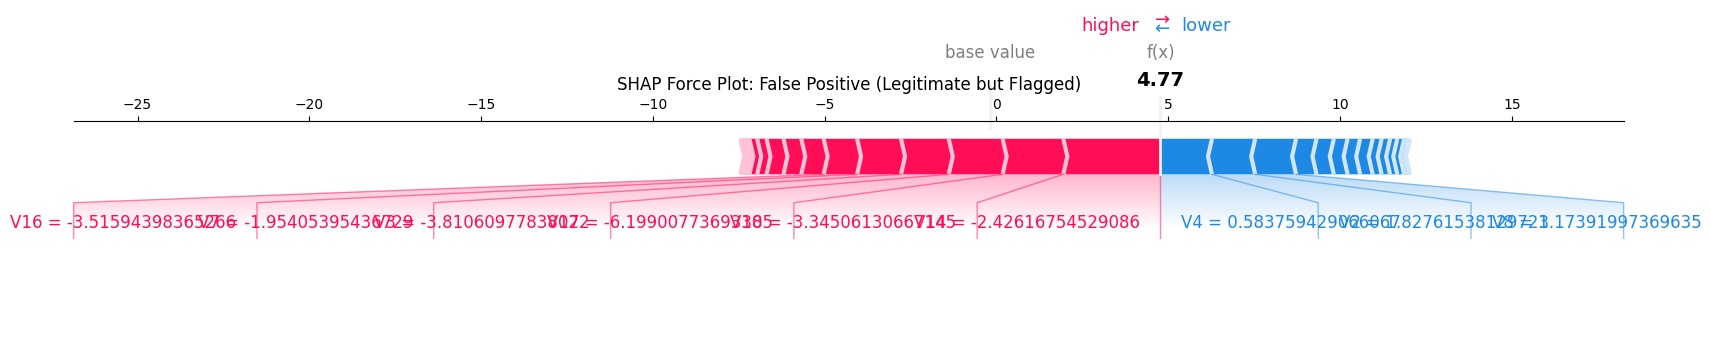

Generating Force Plot for: False Negative (Missed Fraud) (Index: 9179)


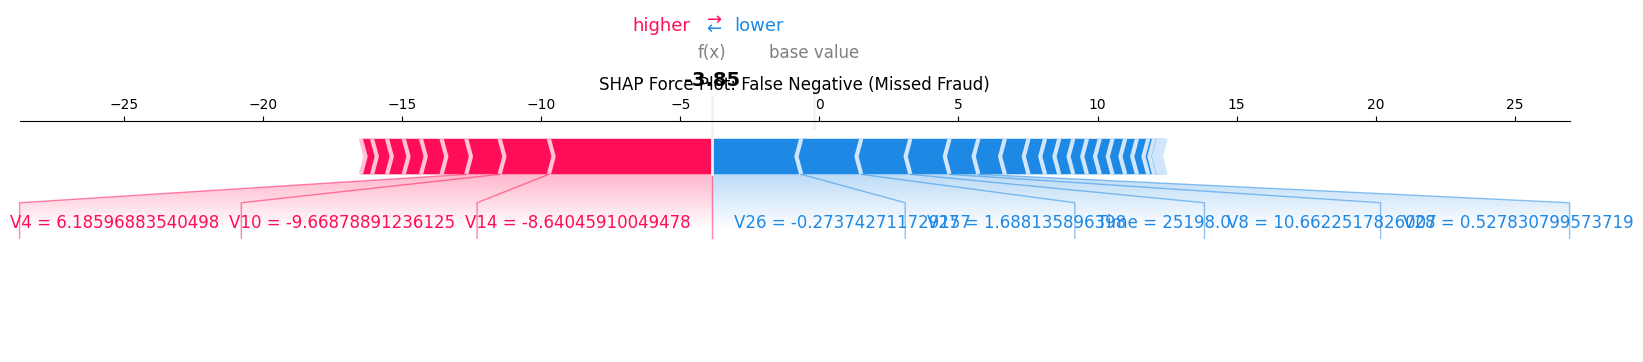

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# NOTE: If running in a Jupyter Notebook, initialize JS visualization for SHAP
shap.initjs()

# ==========================================
# 1. Feature Importance Baseline (XGBoost Built-in)
# ==========================================
print("Generating Built-in Feature Importance...")

# Extract feature importances and feature names
importances = best_xgb.feature_importances_
features = X_test.columns

# Create a DataFrame and sort
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(10)

# Plot Built-in Importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Top 10 Features: XGBoost Built-in Importance')
plt.xlabel('Relative Importance (Gain)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# ==========================================
# 2. SHAP Analysis: Global Explainability
# ==========================================
print("Calculating SHAP values (this may take a moment)...")

# Initialize the TreeExplainer
explainer = shap.TreeExplainer(best_xgb)

# Calculate SHAP values for the test set
# (If X_test is very large, consider using a random sample like X_test.sample(2000) to speed this up)
shap_values = explainer.shap_values(X_test)

# Generate SHAP Summary Plot
plt.figure()
plt.title('SHAP Summary Plot (Global Feature Importance)')
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.show()

# ==========================================
# 3. SHAP Analysis: Local Explainability (Force Plots)
# ==========================================
# First, identify the indices for TP, FP, and FN in our test set
y_test_array = y_test.values
y_pred_array = y_pred # Assuming y_pred from Task 2 is a numpy array

tp_indices = np.where((y_test_array == 1) & (y_pred_array == 1))[0]
fp_indices = np.where((y_test_array == 0) & (y_pred_array == 1))[0]
fn_indices = np.where((y_test_array == 1) & (y_pred_array == 0))[0]

# Helper function to plot and save/show force plots
def generate_force_plot(idx, title_label):
    print(f"Generating Force Plot for: {title_label} (Index: {idx})")
    # Generate the plot
    p = shap.force_plot(
        explainer.expected_value, 
        shap_values[idx, :], 
        X_test.iloc[idx, :], 
        matplotlib=True, # Set to False if using Jupyter and prefer interactive JS plots
        show=False
    )
    plt.title(f'SHAP Force Plot: {title_label}')
    plt.show()

# Ensure we have at least one of each before plotting
if len(tp_indices) > 0:
    generate_force_plot(tp_indices[0], "True Positive (Correctly Flagged Fraud)")
if len(fp_indices) > 0:
    generate_force_plot(fp_indices[0], "False Positive (Legitimate but Flagged)")
if len(fn_indices) > 0:
    generate_force_plot(fn_indices[0], "False Negative (Missed Fraud)")